<a href="https://colab.research.google.com/github/tegarpng/Projek-Kelompok-29/blob/main/Percobaan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets

In [2]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadtegarbijanta
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/tombackert/brain-tumor-mri-data


100%|██████████| 151M/151M [00:01<00:00, 88.5MB/s]


## **Mengambil data kaggle**
Pada bagian ini, digunakan library opendatasets untuk mengambil data dari website kaggle, ini digunakan agar kita tidak perlu mendownload file kaggle nya. Ini membuat pengambilan data nya lebih efisien.

In [3]:
import os
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

## **Import Library**
Melakukan import terhadap library yang digunakan untuk menyelesaikan tahap percobaan 2 projek ini.

In [4]:
data = []
labels = []
file_name = []

# Batasi 300 gambar per folder agar pengerjaan cepat & seimbang
class_counters = {'Brain Tumor': 0, 'Healthy': 0, 'glioma': 0, 'notumor': 0}
dataset_path = "brain-tumor-mri-data"

for root, dirs, files in os.walk(dataset_path):
    folder_aktif = os.path.basename(root)
    if folder_aktif in ['Brain Tumor', 'Healthy', 'glioma', 'notumor']:
        for filename in files:
            if class_counters[folder_aktif] >= 300:
                break
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(root, filename)
                img = cv.imread(img_path)
                if img is not None:

                    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                    img_gray = cv.resize(img_gray, (256, 256))

                    data.append(img_gray)
                    labels.append(folder_aktif)
                    file_name.append(filename)
                    class_counters[folder_aktif] += 1

data = np.array(data, dtype=object)
labels = np.array(labels)
print(f"Sukses membaca data mentah! Total data awal: {len(data)} gambar.")

Sukses membaca data mentah! Total data awal: 600 gambar.


## **Data Loading**
Pada bagian ini, dilakukan pembacaan data dari file kaggle yang telah diambil pada bagian sebelumnya. Pada bagian ini juga digunakan variabel data sebagai tempat menyimpan data yang akan digunakan. Data yang digunakan untuk percobaan ini adalah 300 data saja, jadi setiap kelas yang akan dianalisis akan menggunakan 300 data. Pada bagian ini setiap data sudah diubah menjadi grayscale dan di resize dengan ukuran 256x256 ini, hal ini dilakukan karena processing yang di lakukan pada percobaan 2 ini menggunakan preprocessing grayscale dan resize. Preprocessing yang dilakukan pada tahap ini dibuat agar kita tidak perlu melakukan kembali preprocessing berikut pada tahap data processing.

In [5]:
unique, counts = np.unique(labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"Kelas {u}: {c} gambar")
print(f"Total data: {len(data)} gambar")

Kelas glioma: 300 gambar
Kelas notumor: 300 gambar
Total data: 600 gambar


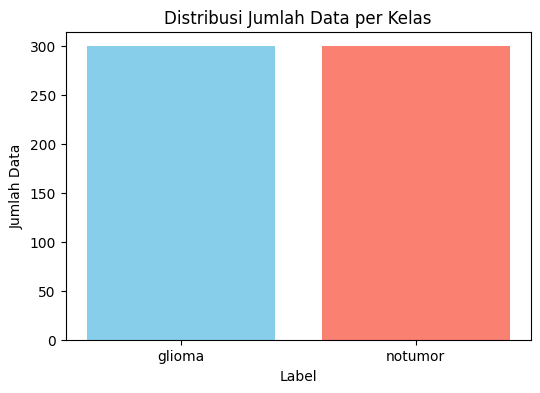

In [6]:
plt.figure(figsize=(6,4))
plt.bar(unique, counts, color=['skyblue','salmon'])
plt.title('Distribusi Jumlah Data per Kelas')
plt.xlabel('Label')
plt.ylabel('Jumlah Data')
plt.show()

##

In [7]:
def median(image, rowkernel, columnkernel):
    row, column = int(rowkernel/2), int(columnkernel/2)
    image_pad = np.pad(image, [(row, row), (column, column)], mode="edge")
    result = np.zeros(image.shape)

    for i in range(row, image.shape[0] + row):
        for j in range(column, image.shape[1] + column):
            submatrix = image_pad[i-row:i+row+1, j-column:j+column+1]
            result[i-row, j-column] = np.median(submatrix)

    return result.astype(np.uint8)

## Fungsi Median Filter


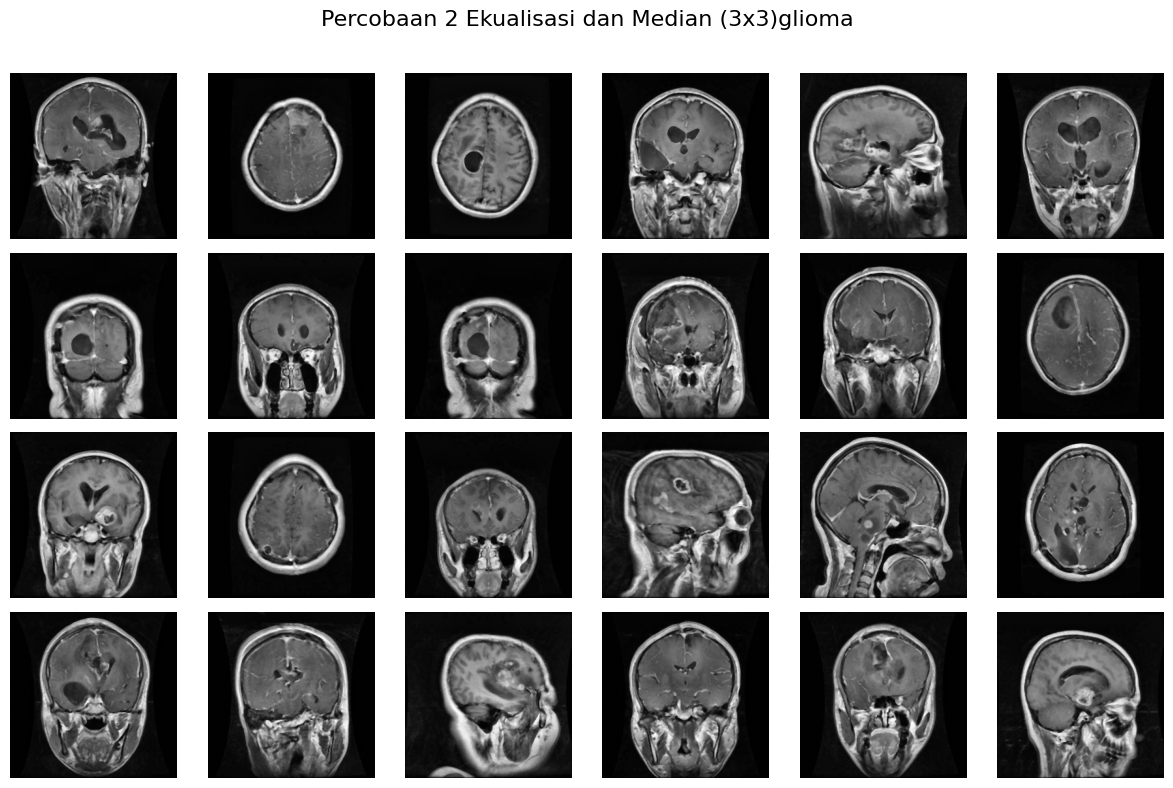

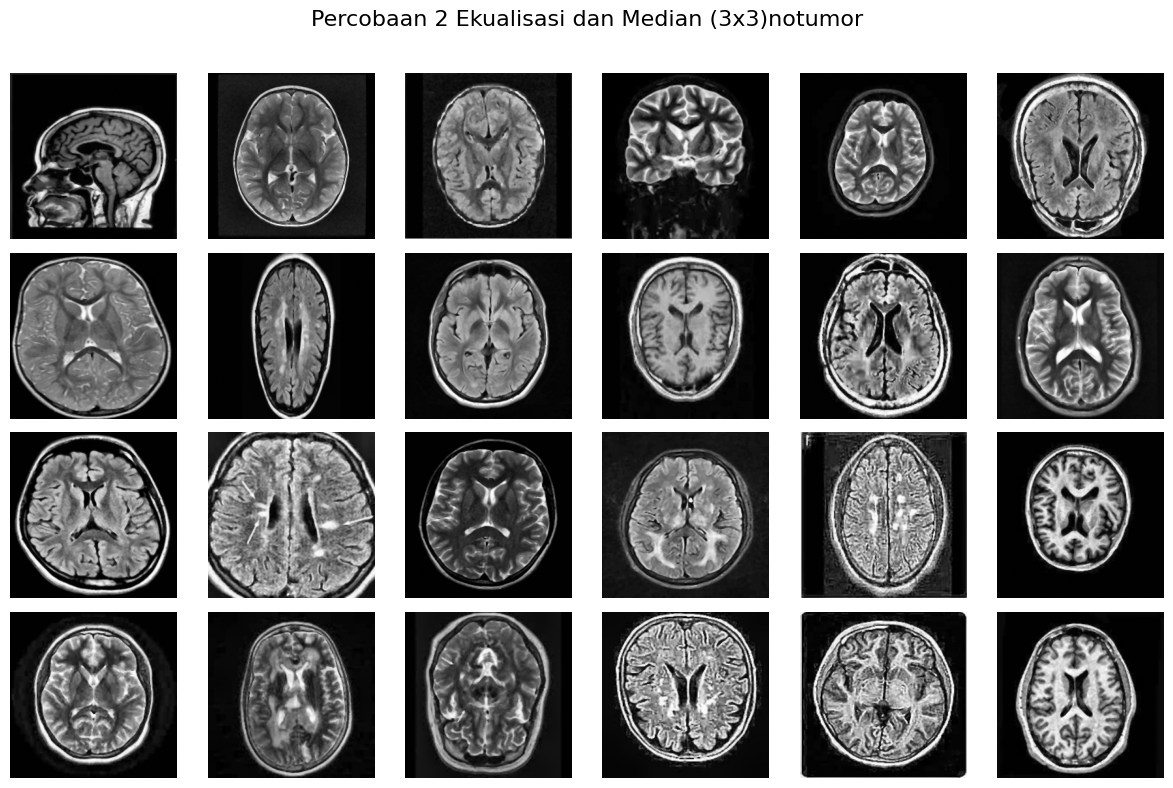

In [60]:
def percobaan2(img):
    img = img.astype(np.uint8)
    clahe = cv.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8,8))

    equalized = clahe.apply(img)
    img_equal = median(equalized, 3, 3)
    return img_equal

dataPreprocessed = [percobaan2(img_gray) for img_gray in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    # Ambil semua indeks gambar dari label ini
    idxs = [j for j, l in enumerate(labels) if l == label]

    # Buat grid 7x12 (cukup untuk 84 gambar, 7*12 = 84)
    fig, axs = plt.subplots(4, 6, figsize=(12, 8))
    fig.suptitle(f'Percobaan 2 Ekualisasi dan Median (3x3){label}', fontsize=16)

    for k in range(24):
        plt.subplot(4, 6, k + 1)
        plt.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # beri ruang untuk judul
    plt.show()

## PERCOBAAN 2 (CLAHE, MEDIAN FILTER)
Pada bagian ini dilakukan percobaan clahe dan median filter untuk melakukan klasifikasi terhadap citra yang merupakan tumor otak dan otak yang sehat. Tahap CLAHE dilakukan untuk mendapatkan hasil citra yang lebih tajam yang dimana hal ini sebenernya dapat dilakukan menggunakan fungsi ekualisasi biasa, namun hasil didapatkan saat menggunakan ekualisasi biasa kurang bagus yang dimana noise yang dihasilkan lebih banyak. Penggunaan CLAHE ini memiliki hasil ekualisasi yang lebih bersih dan tajam. Setelah penggunaan CLAHE, diterapkan median filter 3x3 untuk mendapatkan hasil noise yang lebih kecil, hal ini membuat hasil CLAHE tadi yang sudah lumayan tajam dengan noise yang sedikit dapat menghasilkan citra yang lebih tajam lagi dan noise yang lebih sedikit lagi.

In [76]:
for i in range(len(dataPreprocessed)):
    dataPreprocessed[i] = dataPreprocessed[i].astype(np.uint8)

print(len(dataPreprocessed))
# for i in range(len(X_data)): # Loop through each image and do preprocessing

600


In [77]:
def glcm(img, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(img, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [78]:

def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [79]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

In [80]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

In [81]:

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(dataPreprocessed)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)


for i in range(len(dataPreprocessed)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(dataPreprocessed)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(dataPreprocessed)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(dataPreprocessed)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(dataPreprocessed)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)


In [82]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
from google.colab import files
files.download('hasil_ekstraksi_2.csv')

display(hasilEkstrak)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,gl-0238.jpg,glioma,181.978339,263.399277,132.668903,292.108912,0.544912,0.479890,0.556873,0.476304,...,0.042362,0.039154,0.200745,0.197805,0.205819,0.197873,0.965058,0.949468,0.974546,0.943960
1,gl-1232.jpg,glioma,92.266881,155.096563,70.781036,145.772887,0.731132,0.691124,0.739898,0.691084,...,0.122324,0.115522,0.347177,0.339647,0.349748,0.339885,0.982205,0.970153,0.986349,0.971947
2,gl-0734.jpg,glioma,99.637684,172.592972,89.924418,175.501484,0.659830,0.609002,0.661008,0.605721,...,0.095758,0.090453,0.309547,0.301044,0.309448,0.300754,0.983484,0.971437,0.985094,0.970956
3,gl-0054.jpg,glioma,228.616330,358.639754,189.479779,373.642384,0.555070,0.497101,0.568222,0.499297,...,0.047946,0.044678,0.215033,0.211445,0.218965,0.211371,0.967379,0.948866,0.972976,0.946727
4,gl-1345.jpg,glioma,153.996553,281.652395,170.661213,308.586498,0.445421,0.355953,0.440669,0.352549,...,0.003719,0.002739,0.061933,0.052937,0.060984,0.052335,0.977754,0.959284,0.975348,0.955390
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,no-1210.jpg,notumor,186.170251,261.218685,97.392693,259.024421,0.648275,0.619430,0.664561,0.614527,...,0.262871,0.257749,0.509292,0.507865,0.512709,0.507690,0.976466,0.967036,0.987689,0.967313
596,no-0137.jpg,notumor,718.162316,1311.311449,772.891192,1314.287351,0.355906,0.295861,0.374617,0.298525,...,0.028037,0.026582,0.166430,0.162534,0.167443,0.163039,0.940180,0.890650,0.935633,0.890402
597,no-0018.jpg,notumor,341.671890,547.932687,263.675766,546.196125,0.532395,0.484718,0.552761,0.486122,...,0.026441,0.023016,0.155697,0.151448,0.162607,0.151709,0.957184,0.931452,0.966970,0.931670
598,no-0013.jpg,notumor,262.765839,447.255010,225.616805,459.615917,0.479138,0.423671,0.507096,0.423167,...,0.045369,0.042837,0.212799,0.206637,0.212999,0.206971,0.971674,0.951798,0.975678,0.950466


<Axes: >

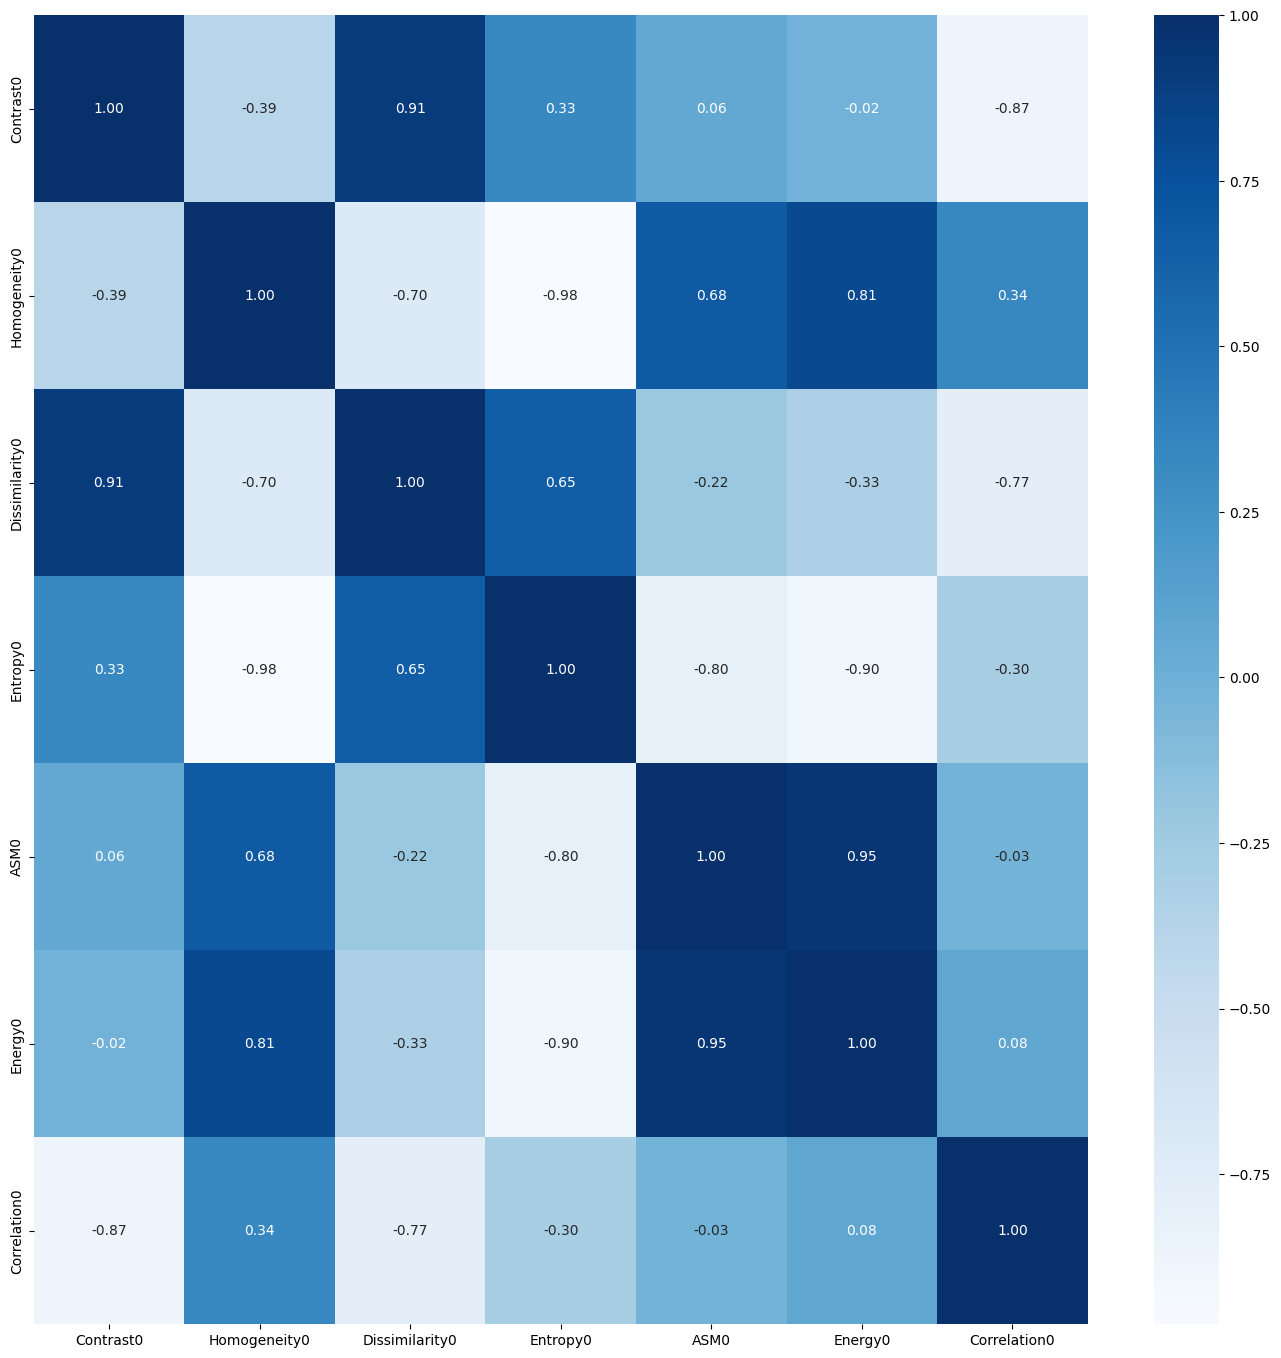

In [83]:
correlation = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation.shape[0],), True, dtype=bool)
for i in range(correlation.shape[0]):
	for j in range(i+1, correlation.shape[0]):
		if correlation.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

In [84]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(480, 7)
(120, 7)


In [85]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

In [86]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [87]:

# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

      glioma       1.00      0.98      0.99       238
     notumor       0.98      1.00      0.99       242

    accuracy                           0.99       480
   macro avg       0.99      0.99      0.99       480
weighted avg       0.99      0.99      0.99       480

[[234   4]
 [  1 241]]
Accuracy: 0.9895833333333334

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.91      0.98      0.95        62
     notumor       0.98      0.90      0.94        58

    accuracy                           0.94       120
   macro avg       0.95      0.94      0.94       120
weighted avg       0.94      0.94      0.94       120

[[61  1]
 [ 6 52]]
Accuracy: 0.9416666666666667


In [88]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.88      0.97      0.92       238
     notumor       0.96      0.87      0.92       242

    accuracy                           0.92       480
   macro avg       0.92      0.92      0.92       480
weighted avg       0.92      0.92      0.92       480

[[230   8]
 [ 31 211]]
Accuracy: 0.91875

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.87      0.97      0.92        62
     notumor       0.96      0.84      0.90        58

    accuracy                           0.91       120
   macro avg       0.92      0.91      0.91       120
weighted avg       0.91      0.91      0.91       120

[[60  2]
 [ 9 49]]
Accuracy: 0.9083333333333333


In [89]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

      glioma       0.93      0.98      0.95       238
     notumor       0.98      0.93      0.95       242

    accuracy                           0.95       480
   macro avg       0.95      0.95      0.95       480
weighted avg       0.95      0.95      0.95       480

[[233   5]
 [ 18 224]]
Accuracy: 0.9520833333333333

------Testing Set------
              precision    recall  f1-score   support

      glioma       0.85      0.98      0.91        62
     notumor       0.98      0.81      0.89        58

    accuracy                           0.90       120
   macro avg       0.91      0.90      0.90       120
weighted avg       0.91      0.90      0.90       120

[[61  1]
 [11 47]]
Accuracy: 0.9


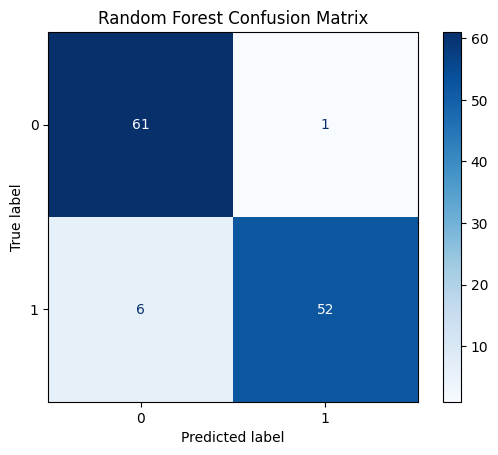

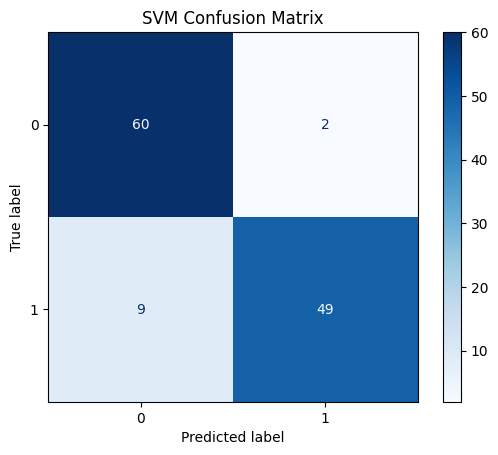

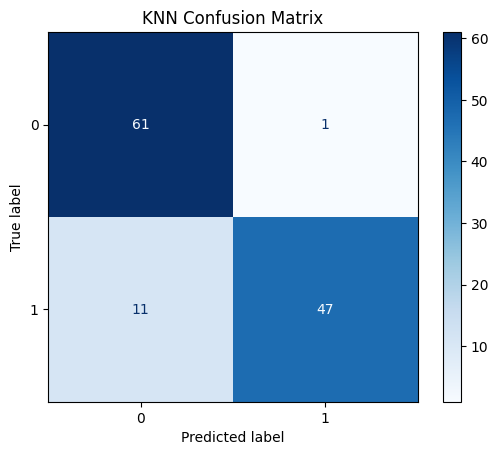

In [90]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")